In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv')

In [4]:
df

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
...,...,...,...,...,...,...,...,...,...
4995,organic_search,education,employed,asia,45834.0,2,2,0.37,1
4996,NaN,technology,employed,north_america,84831.0,2,5,0.51,0
4997,organic_search,finance,employed,asia,53636.0,4,6,0.75,1
4998,referral,technology,employed,africa,69430.0,4,8,0.79,1


In [5]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [6]:
categorical = ['lead_source','industry','employment_status','number_of_courses_viewed',
               'interaction_count','location']
numerical = ['annual_income', 'lead_score']
# 'number_of_courses_viewed','interaction_count'

In [7]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [8]:
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [9]:
df_full_train, df_test = train_test_split(df,test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train,test_size=0.25,random_state=1)

In [10]:
y_full_train = df_full_train.converted.values
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

In [11]:
# roc_auc_score(y_train,df_train['lead_score'])
numerical_variables = ['lead_score', 'number_of_courses_viewed', 'interaction_count',
                            'annual_income']
for var in numerical_variables:
    print(f'{var} {roc_auc_score(y_train,df_train[var])}')

lead_score 0.7882254810906102
number_of_courses_viewed 0.7229894623989618
interaction_count 0.7649203047563227
annual_income 0.6081977776250831


# Training the model

In [68]:
def train_model(df_train,y_train, C =1.0):
    dicts = df_train[numerical + categorical].to_dict(orient = 'records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(solver='liblinear', C =C, max_iter=1000)
    model.fit(X_train,y_train)

    return dv,model

In [13]:
train_model(df_train,y_train)

(DictVectorizer(sparse=False),
 LogisticRegression(max_iter=1000, solver='liblinear'))

In [16]:
def predict(df,dv,model):
    dicts = df[numerical + categorical].to_dict(orient = 'records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]
    return y_pred

In [17]:
dv,model = train_model(df_train,y_train)
y_pred = predict(df_val,dv,model)
roc_auc_score(y_val,y_pred)

0.7318222288173319

# Question 3

In [22]:
def metrics(t,y_pred,y_val):
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred>=t)
    predict_negtive =  (y_pred<t)

    tp = (actual_positive & predict_positive).sum() # tp -> true positive
    tn = (actual_negative & predict_negtive).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negtive & actual_positive).sum()

    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    return precision,recall

/var/folders/cn/zqq978fn6fdgkxky_09260kw0000gn/T/ipykernel_1840/2272722181.py:13: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp/(tp+fp)
/var/folders/cn/zqq978fn6fdgkxky_09260kw0000gn/T/ipykernel_1840/531104691.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


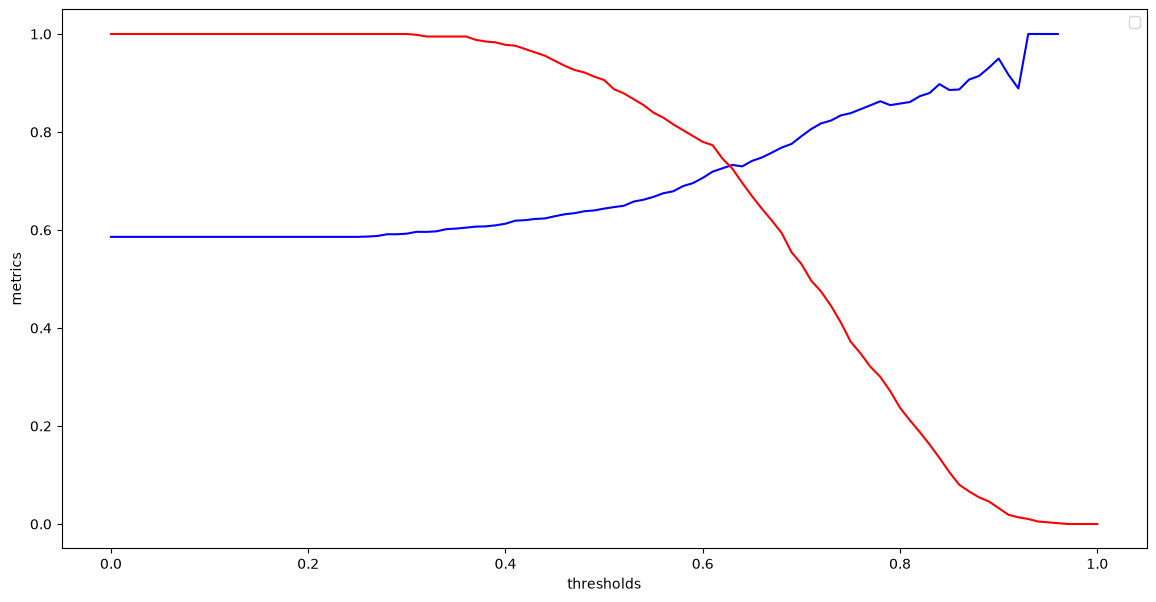

In [39]:
thresholds = np.linspace(0,1,101)
precision = []
recall = []

for t in thresholds:
    p,r = metrics(t,y_pred,y_val)
    precision.append(p)
    recall.append(r)

plt.figure(figsize=(14,7))
plt.plot(thresholds, precision, color='blue')
plt.plot(thresholds, recall, color='red')

plt.xlabel('thresholds')
plt.ylabel('metrics')
plt.legend()
# plt.xlim(0.58, 0.68)
# plt.xticks(np.arange(0.58, 0.681, 0.01))
# plt.grid()

/var/folders/cn/zqq978fn6fdgkxky_09260kw0000gn/T/ipykernel_1840/2786977140.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


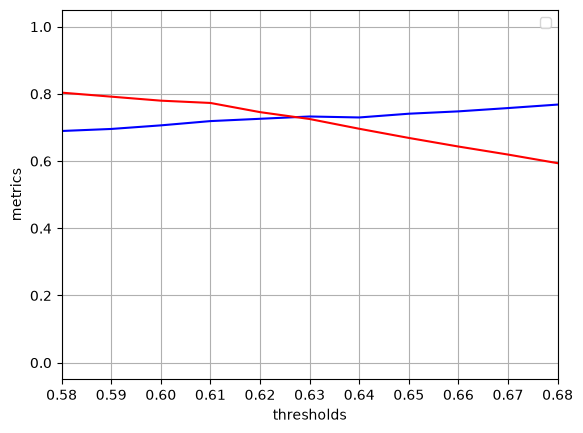

In [40]:
plt.plot(thresholds, precision, color='blue')
plt.plot(thresholds, recall, color='red')

plt.xlabel('thresholds')
plt.ylabel('metrics')
plt.legend()
plt.xlim(0.58, 0.68)
plt.xticks(np.arange(0.58, 0.681, 0.01))
plt.grid()

In [53]:
def f1_score_calculator(p,r):
    score = 2*((p*r)/(p+r))
    return score

In [61]:
f1_score = []
max_f1_score = 0
max_threshold = 0
for i in range(101):
    score = f1_score_calculator(precision[i],recall[i])
    f1_score.append(score)
    if score > max_f1_score:
        max_f1_score = score
        max_threshold = i

# plt.plot(thresholds,f1_score)
max_threshold,max_f1_score

(41, np.float64(0.7576158940397352))

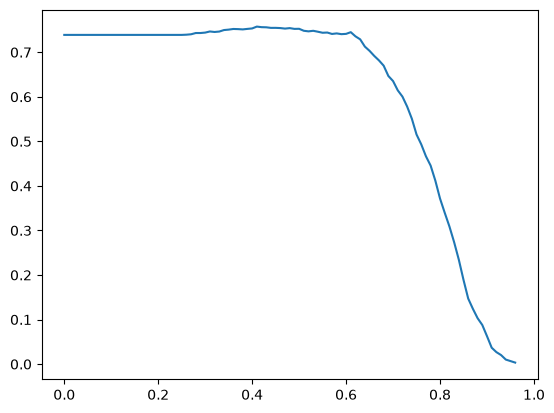

In [62]:
plt.plot(thresholds,f1_score)


# 5 - Fold CV

In [64]:
from tqdm.auto import tqdm

In [65]:
kfold = KFold(n_splits=5, shuffle= True, random_state= 1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv,model = train_model(df_train[numerical+categorical],y_train)
    y_pred = predict(df_val,dv,model)

    score = roc_auc_score(y_val,y_pred)
    scores.append(score)

np.std(scores)    


np.float64(0.006853233151022138)

In [69]:

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=5, shuffle= True, random_state= 1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv,model = train_model(df_train[numerical+categorical],y_train, C)
        y_pred = predict(df_val,dv,model)

        score = roc_auc_score(y_val,y_pred)
        scores.append(score)

    np.std(scores)    
    print(f'C: {C} Mean: {np.mean(scores)} Std: {np.std(scores)}')

  0%|          | 0/3 [00:00<?, ?it/s]

C: 1e-06 Mean: 0.6167342250714795 Std: 0.018669799234831475
C: 0.001 Mean: 0.7491721776030379 Std: 0.009996375455700753
C: 1 Mean: 0.7317269710972524 Std: 0.006853233151022138
